In [1]:
import sys
import numpy
import pandas
import matplotlib
import seaborn
import scipy

print('Python: {}'.format(sys.version))
print('Numpy: {}'.format(numpy.__version__))
print('Pandas: {}'.format(pandas.__version__))
print('Matplotlib: {}'.format(matplotlib.__version__))
print('Seaborn: {}'.format(seaborn.__version__))
print('Scipy: {}'.format(scipy.__version__))

Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
Numpy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scipy: 1.16.2


In [2]:
# Import the necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset from the csv file using pandas
data = pd.read_csv('creditcard.csv')

In [5]:
# Start exploring the dataset
print(data.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [6]:
# Taking sample of dataset
data = data.sample(frac = 0.1, random_state = 1)

# Print the shape of the data
print(data.shape)

# V1 - V28 are the results of a PCA Dimensionality reduction to protect user identities and sensitive features

(2188, 31)


In [7]:
print(data.describe())

               Time           V1           V2           V3           V4  \
count   2188.000000  2188.000000  2188.000000  2188.000000  2188.000000   
mean   16645.510055    -0.252406     0.238006     0.764436     0.250899   
std    10887.732761     1.729625     1.318605     1.578868     1.455236   
min        0.000000   -19.856322    -7.796805   -22.464083    -4.657545   
25%     5442.000000    -0.986498    -0.328039     0.294625    -0.635078   
50%    18039.000000    -0.341201     0.201353     0.899101     0.197521   
75%    27483.500000     1.155909     0.860677     1.539674     1.091923   
max    31906.000000     1.622188    12.095893     3.934998    11.270352   

                V5           V6           V7           V8           V9  ...  \
count  2188.000000  2188.000000  2188.000000  2188.000000  2188.000000  ...   
mean     -0.159708     0.111291    -0.130887    -0.007493     0.610901  ...   
std       1.205635     1.282540     1.169800     1.359599     1.266058  ...   
min     

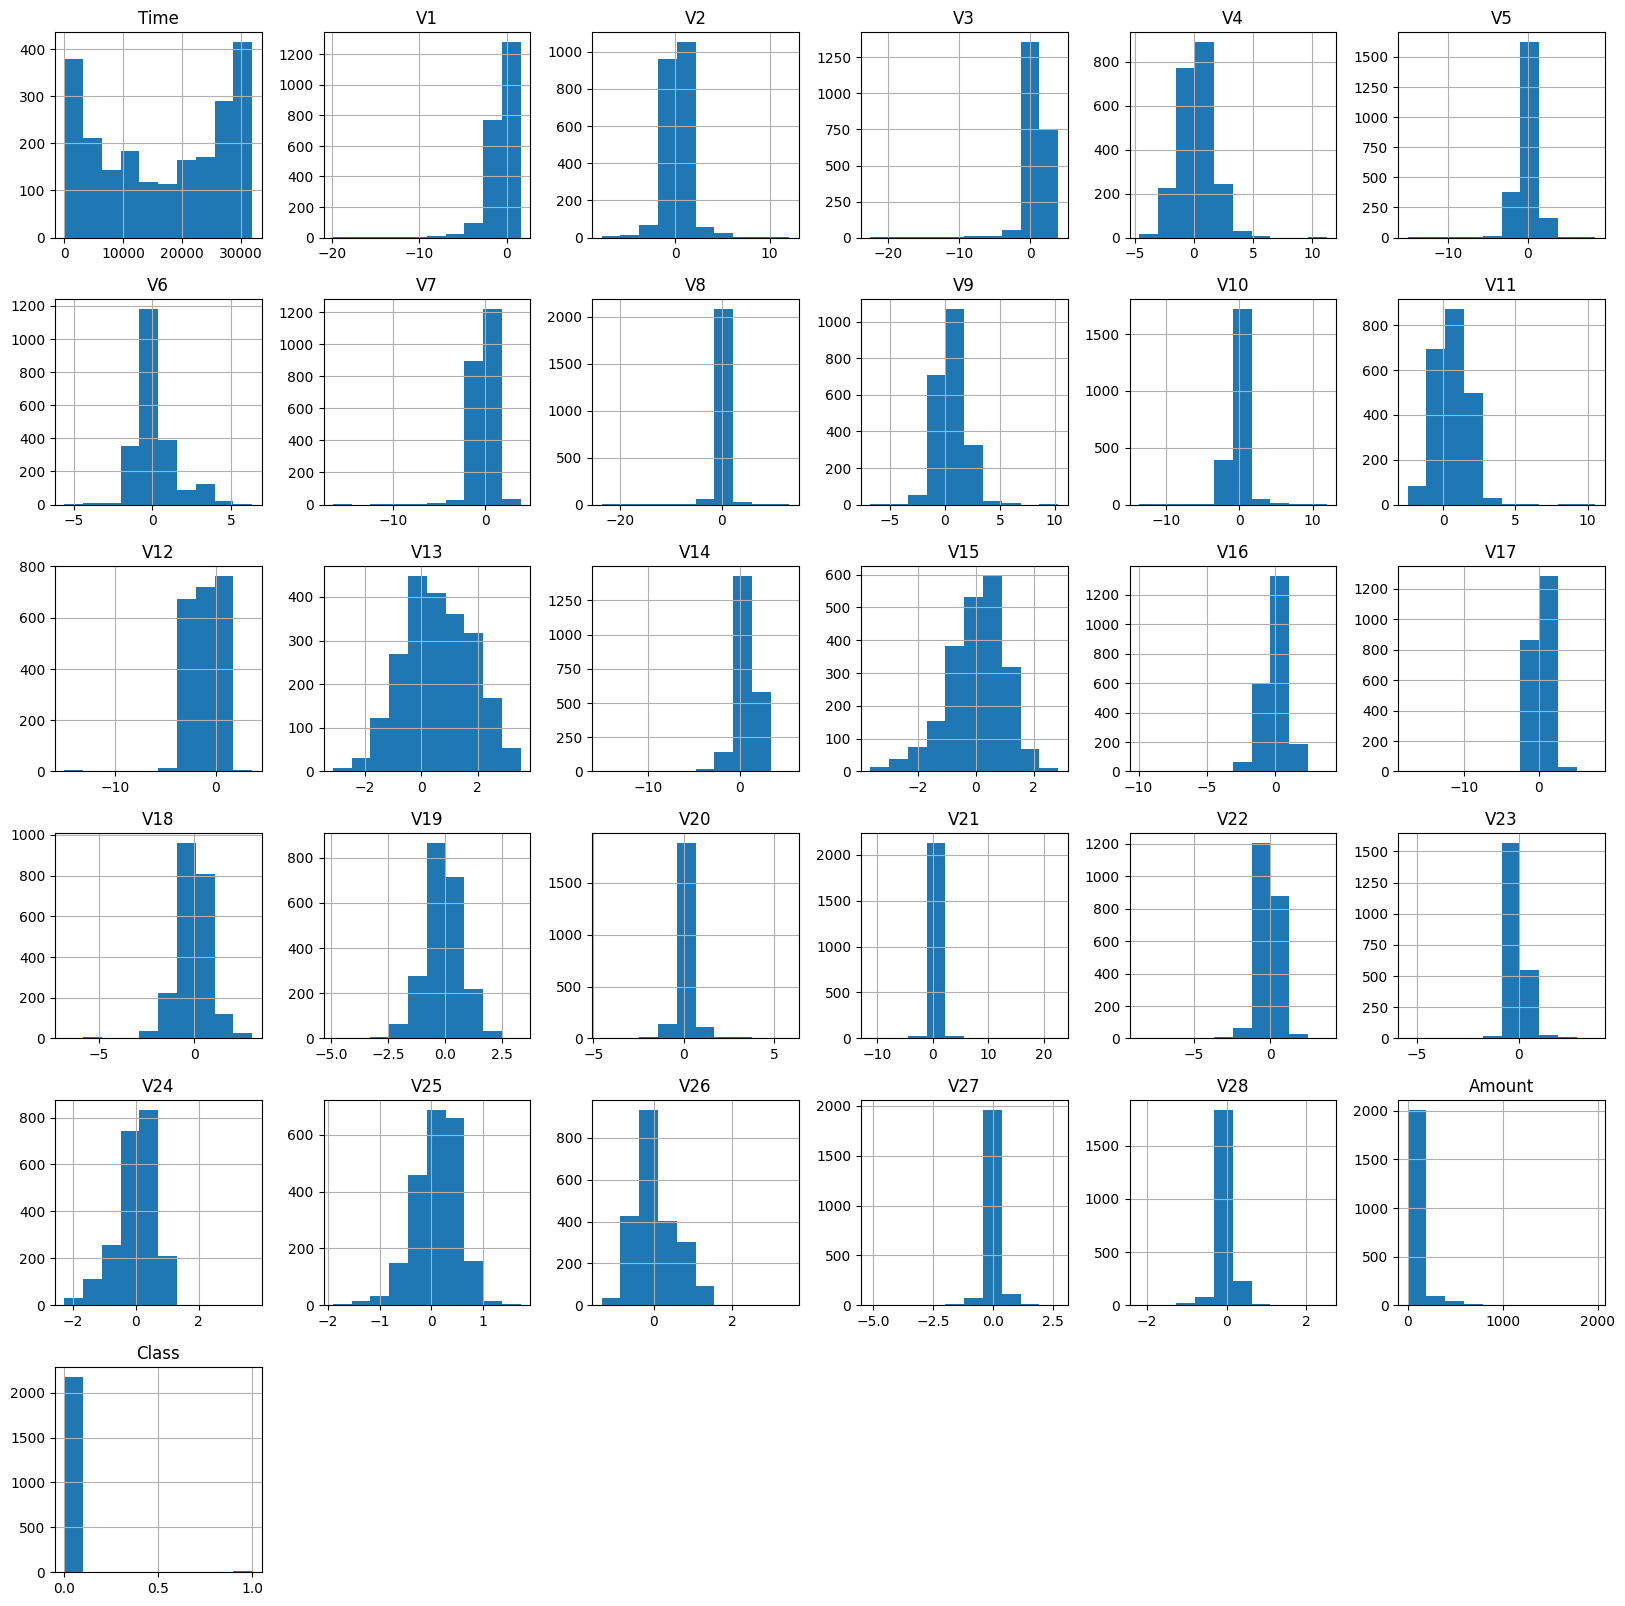

In [8]:
# Plot histograms of each parameter
data.hist(figsize = (20, 20))
plt.show()

In [9]:
# Determine number of fraud cases in dataset
Fraud = data[data['Class'] == 1]
Valid = data[data['Class'] == 0]

outlier_fraction = len(Fraud)/float(len(Valid))
print("Fraction of outliers:",outlier_fraction)

print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

Fraction of outliers: 0.004591368227731864
Fraud Cases: 10
Valid Transactions: 2178


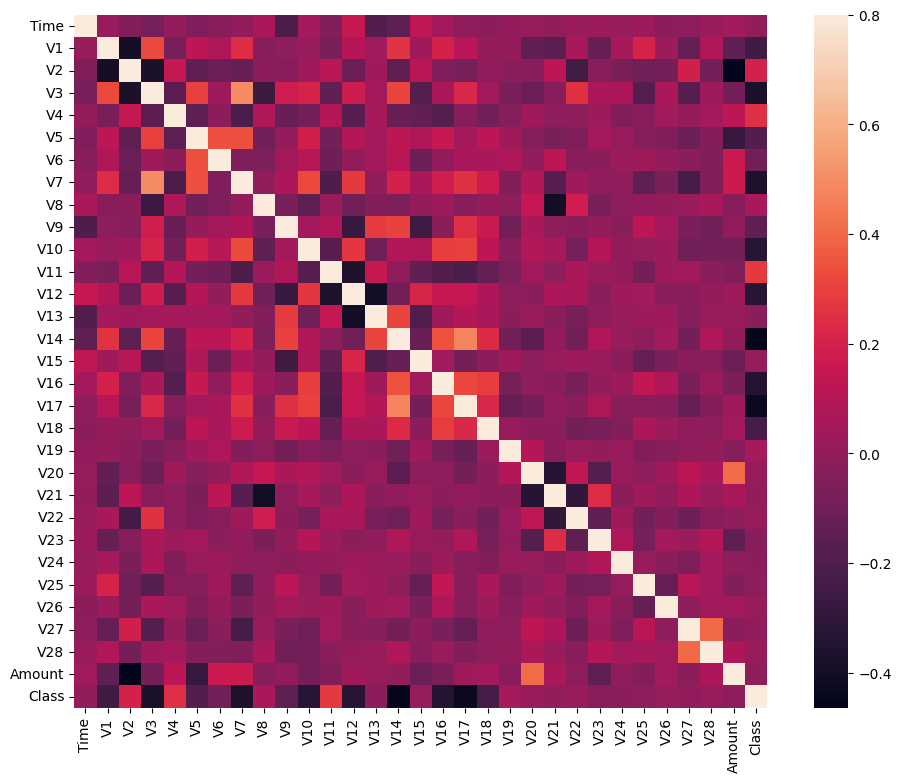

In [10]:
# Correlation matrix
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))

sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [11]:
# Get all the columns from the dataframe
columns = data.columns.tolist()

# Filter the columns to remove data we do not want
columns = [c for c in columns if c not in ["Class"]]

# Store the variable we'll be predicting on
target = "Class"

X = data[columns]
Y = data[target]

# Print the shapes of X and Y
print(X.shape)
print(Y.shape)

(2188, 30)
(2188,)
